## 1. Setup & Data Validation

In [37]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt

# Resolve project root once, regardless of where the notebook runs from
PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> repo root
DB_PATH = PROJECT_ROOT / "data" / "processed" / "bluestock_mf.db"
RAW_PATH = PROJECT_ROOT / "data" / "raw"

conn = sqlite3.connect(DB_PATH)

In [38]:

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
print(benchmark.shape)
print(benchmark.dtypes)
print(benchmark.head())

(8050, 3)
date            object
index_name      object
close_value    float64
dtype: object
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [39]:
print(benchmark['index_name'].unique())
print(benchmark.groupby('index_name')['date'].agg(['min', 'max', 'count']))

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']
                        min         max  count
index_name                                    
BSE_SMALLCAP     2022-01-03  2026-05-29   1150
CRISIL_GILT      2022-01-03  2026-05-29   1150
CRISIL_LIQUID    2022-01-03  2026-05-29   1150
NIFTY100         2022-01-03  2026-05-29   1150
NIFTY50          2022-01-03  2026-05-29   1150
NIFTY500         2022-01-03  2026-05-29   1150
NIFTY_MIDCAP150  2022-01-03  2026-05-29   1150


In [40]:
nav_dates = pd.read_sql("SELECT MIN(date) as min_date, MAX(date) as max_date, COUNT(DISTINCT date) as n_dates FROM fact_nav", conn)
print(nav_dates)

     min_date    max_date  n_dates
0  2022-01-03  2026-05-29     1608


In [41]:
# Check fact_nav date frequency
nav_all_dates = pd.read_sql("SELECT DISTINCT date FROM fact_nav ORDER BY date", conn)
nav_all_dates['date'] = pd.to_datetime(nav_all_dates['date'])
print(nav_all_dates['date'].diff().value_counts().head())

# Check benchmark date frequency (just NIFTY50)
bm50 = benchmark[benchmark['index_name'] == 'NIFTY50'].copy()
bm50['date'] = pd.to_datetime(bm50['date'])
print(bm50['date'].diff().value_counts().head())

date
1 days    1607
Name: count, dtype: int64
date
1 days    920
3 days    229
Name: count, dtype: int64


### Long fact_nav

In [42]:
nav_long = pd.read_sql("SELECT date, amfi_code, nav FROM fact_nav", conn)
nav_long['date'] = pd.to_datetime(nav_long['date'])
print(nav_long.shape)
nav_long.head()

(64320, 3)


,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


### Pivot Wide

In [43]:
nav_wide = nav_long.pivot(index='date', columns='amfi_code', values='nav')
nav_wide = nav_wide.sort_index()
print(nav_wide.shape)
nav_wide.head()

(1608, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


## 2. Daily Returns

In [44]:
daily_returns = nav_wide.pct_change()
daily_returns = daily_returns.dropna(how='all')  # drop first row (all NaN from pct_change)
print(daily_returns.shape)
daily_returns.head()

(1607, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Distribution Validation

In [45]:
print(daily_returns.describe().T[['mean', 'std', 'min', 'max']])

               mean       std       min       max
amfi_code                                        
100016     0.000101  0.007749 -0.024744  0.032145
100025     0.000122  0.002081 -0.008188  0.008837
100033     0.000772  0.010097 -0.044238  0.041954
101206     0.000609  0.007768 -0.038121  0.033956
101207     0.000303  0.013741 -0.051847  0.054851
101208     0.000173  0.000291 -0.000766  0.001247
102885     0.000482  0.006844 -0.021104  0.025565
102886     0.000079  0.009659 -0.036695  0.040745
102887     0.000461  0.008398 -0.031271  0.032386
118632     0.000619  0.007545 -0.028490  0.028218
118633     0.000441  0.007460 -0.025402  0.035913
118634     0.000506  0.013447 -0.058102  0.059304
118635     0.000429  0.006920 -0.025466  0.030547
118636     0.000144  0.002125 -0.008883  0.007708
119092     0.000197  0.007431 -0.023383  0.033626
119093     0.000236  0.007449 -0.029496  0.030558
119094     0.000734  0.010347 -0.040755  0.041591
119095     0.000130  0.013351 -0.048367  0.043110


In [46]:
check = daily_returns.copy()
check['weekday'] = check.index.day_name()
zero_by_weekday = (check.drop(columns='weekday') == 0).mean(axis=1).groupby(check['weekday']).mean()
print(zero_by_weekday)

weekday
Friday       0.000109
Monday       0.000218
Saturday     1.000000
Sunday       1.000000
Thursday     0.000000
Tuesday      0.000109
Wednesday    0.000217
dtype: float64


**Data quality note:** `fact_nav` contains NAV values for every calendar day, including weekends. 
Weekend values are flat-carried forward from the prior trading day (confirmed: 100% zero daily 
return on Sat/Sun vs ~0% on weekdays). All performance metrics from this point use 
`daily_returns_trading` (weekends excluded) to avoid artificially deflating volatility.

In [47]:
# Weekend NAV values are flat-carried forward (confirmed: 100% zero returns on Sat/Sun)
# Filter to trading days only so volatility isn't artificially deflated,
# and so this aligns with benchmark data (which is trading-days-only)
daily_returns_trading = daily_returns[daily_returns.index.dayofweek < 5]  # Mon=0 ... Fri=4
print(daily_returns_trading.shape)

(1149, 40)


### Anchor dates

In [48]:
nav_trading = nav_wide[nav_wide.index.dayofweek < 5]
latest_date = nav_trading.index.max()
print("Latest date:", latest_date)
print("Earliest date:", nav_trading.index.min())

Latest date: 2026-05-29 00:00:00
Earliest date: 2022-01-03 00:00:00


### Nearest trading date function

In [49]:
def nearest_trading_date(target_date, available_dates):
    # available_dates must be sorted; finds the closest date <= target_date if possible
    idx = available_dates.searchsorted(target_date)
    if idx == 0:
        return available_dates[0]
    if idx == len(available_dates):
        return available_dates[-1]
    # pick whichever side is closer
    before = available_dates[idx - 1]
    after = available_dates[idx]
    return before if (target_date - before) <= (after - target_date) else after

dates_sorted = nav_trading.index.sort_values()
date_1yr_ago = nearest_trading_date(latest_date - pd.DateOffset(years=1), dates_sorted)
date_3yr_ago = nearest_trading_date(latest_date - pd.DateOffset(years=3), dates_sorted)
inception_date = dates_sorted[0]

print("1yr anchor:", date_1yr_ago)
print("3yr anchor:", date_3yr_ago)
print("Inception:", inception_date)

1yr anchor: 2025-05-29 00:00:00
3yr anchor: 2023-05-29 00:00:00
Inception: 2022-01-03 00:00:00


## 3. CAGR calculation

In [50]:
def compute_cagr(nav_series, start_date, end_date, n_years):
    start_nav = nav_series.loc[start_date]
    end_nav = nav_series.loc[end_date]
    return (end_nav / start_nav) ** (1 / n_years) - 1

cagr_1yr = compute_cagr(nav_trading, date_1yr_ago, latest_date, 1)
cagr_3yr = compute_cagr(nav_trading, date_3yr_ago, latest_date, 3)

n_years_inception = (latest_date - inception_date).days / 365.25
cagr_inception = compute_cagr(nav_trading, inception_date, latest_date, n_years_inception)

cagr_table = pd.DataFrame({
    '1yr_cagr': cagr_1yr,
    '3yr_cagr': cagr_3yr,
    f'since_inception_cagr_{n_years_inception:.1f}yr': cagr_inception
})
print(cagr_table.shape)
cagr_table.head(10)

(40, 3)


,1yr_cagr,3yr_cagr,since_inception_cagr_4.4yr
amfi_code,,,
100016,-0.022243,0.012926,0.026371
100025,0.037050,0.039164,0.044582
100033,0.532324,0.324425,0.301232
101206,0.479241,0.289677,0.235384
101207,-0.239860,-0.041524,0.079388
101208,0.072366,0.063158,0.065090
102885,0.202077,0.196673,0.182324
102886,-0.167975,-0.007674,0.011717
102887,0.135831,0.255562,0.168411


**Note:** Dataset spans Jan 2022–May 2026 (around 4.4 years), so a true 5yr CAGR cannot be computed. 
Reporting 1yr, 3yr, and since-inception (around 4.4yr) CAGR instead, using nearest available 
trading dates as anchors per fund-industry convention.

## 4. Sharpe Ratio

In [51]:
Rf_annual = 0.065
trading_days = 252

mean_daily_return = daily_returns_trading.mean()
std_daily_return = daily_returns_trading.std()

Rp_annual = mean_daily_return * trading_days
sharpe_ratio = (Rp_annual - Rf_annual) / (std_daily_return * np.sqrt(trading_days))

sharpe_ranked = sharpe_ratio.sort_values(ascending=False)
print(sharpe_ranked.head(10))
print(sharpe_ranked.tail(10))

amfi_code
148567    1.448291
120843    1.306744
148569    1.234930
119551    1.208267
120505    1.180101
149323    1.132122
100033    1.093699
118632    1.081659
101206    1.027213
120504    1.026524
dtype: float64
amfi_code
119092    0.030785
119599   -0.057187
119095   -0.075974
120844   -0.088747
100016   -0.201517
102886   -0.205832
119120   -0.226575
118636   -0.356630
100025   -0.567095
101208   -0.815567
dtype: float64


**Data lineage note:** Sharpe ratios computed here (using Rf = 6.5%) diverge sharply from the 
precomputed values in `fact_performance` for low-volatility funds (e.g. amfi_code 120507: 1.45 
here vs 7.68 in fact_performance). Diagnostic check confirms that removing Rf from our formula 
reproduces `fact_performance`'s ranking almost exactly, indicating `fact_performance` was likely 
computed with Rf ≈ 0 rather than a real risk-free rate. This is the same underlying mechanism 
behind the Day 3 finding that debt fund Sharpe ratios appeared unrealistically high: low std 
amplifies whatever the numerator is, whether that inflates the ratio (Rf≈0) or crashes it 
negative (Rf=6.5%, return below the hurdle). This notebook uses Rf = 6.5% per the task 
specification; `fact_performance`'s precomputed Sharpe values should not be used for the 
Fund Scorecard.

## 5. Sortino Ratio

In [52]:
downside_returns = daily_returns_trading.where(daily_returns_trading < 0)
downside_std = downside_returns.std()

sortino_ratio = (Rp_annual - Rf_annual) / (downside_std * np.sqrt(trading_days))

sortino_ranked = sortino_ratio.sort_values(ascending=False)
print(sortino_ranked.head(10))
print(sortino_ranked.tail(10))

amfi_code
148567    2.385644
120843    2.364320
148569    2.146914
119551    2.140267
120505    2.029353
149323    1.875101
118632    1.850133
100033    1.829134
120504    1.805294
101206    1.799563
dtype: float64
amfi_code
119092    0.052574
119599   -0.094387
119095   -0.128186
120844   -0.187723
102886   -0.347222
100016   -0.351047
119120   -0.376767
118636   -0.613525
100025   -0.941821
101208   -1.681038
dtype: float64


**Note:** Ranking pattern matches Sharpe Ratio (same low-volatility funds at both extremes), 
consistent with the mechanism documented above — low std amplifies the numerator's sign/magnitude 
regardless of which denominator (total std vs downside std) is used.

### Prep Nifty 100 benchmark returns

In [53]:
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()
nifty100['date'] = pd.to_datetime(nifty100['date'])
nifty100 = nifty100.set_index('date').sort_index()
nifty100_returns = nifty100['close_value'].pct_change().dropna()
print(nifty100_returns.shape)
nifty100_returns.head()

(1149,)


date
2022-01-04   -0.013540
2022-01-05    0.004003
2022-01-06   -0.002935
2022-01-07    0.006150
2022-01-10   -0.008351
Name: close_value, dtype: float64

### Check overlap with fund returns before merging

In [54]:
common_dates = daily_returns_trading.index.intersection(nifty100_returns.index)
print(f"Fund trading days: {len(daily_returns_trading)}")
print(f"Benchmark trading days: {len(nifty100_returns)}")
print(f"Common dates: {len(common_dates)}")

Fund trading days: 1149
Benchmark trading days: 1149
Common dates: 1149


## 6. Alpha and Beta (OLS Regression vs Nifty 100)

In [55]:
from scipy.stats import linregress

alpha_list = []
beta_list = []
amfi_codes = []

for code in daily_returns_trading.columns:
    fund_returns = daily_returns_trading[code].reindex(common_dates)
    bench_returns = nifty100_returns.reindex(common_dates)
    
    slope, intercept, r_value, p_value, std_err = linregress(bench_returns, fund_returns)
    
    amfi_codes.append(code)
    beta_list.append(slope)
    alpha_list.append(intercept * 252)  # annualized per task spec

alpha_beta_df = pd.DataFrame({
    'amfi_code': amfi_codes,
    'alpha': alpha_list,
    'beta': beta_list
}).set_index('amfi_code')

print(alpha_beta_df.sort_values('alpha', ascending=False).head(10))
print(alpha_beta_df.sort_values('beta', ascending=False).head(10))

              alpha      beta
amfi_code                    
119598     0.303370 -0.023196
149324     0.300579  0.011455
120505     0.292636  0.000549
148569     0.282704  0.018134
120843     0.273305 -0.022830
100033     0.271954  0.005104
148567     0.269838  0.023684
149323     0.265986 -0.002523
119094     0.260767 -0.066265
119551     0.232010 -0.031751
              alpha      beta
amfi_code                    
118634     0.175007  0.103497
119599     0.048824  0.062002
125497     0.177298  0.048820
120506     0.162539  0.041896
120841     0.130429  0.036356
119093     0.082328  0.025883
148567     0.269838  0.023684
101206     0.213998  0.021086
148569     0.282704  0.018134
120842     0.078044  0.018057


In [56]:
r_squared_list = []
p_value_list = []

for code in daily_returns_trading.columns:
    fund_returns = daily_returns_trading[code].reindex(common_dates)
    bench_returns = nifty100_returns.reindex(common_dates)
    slope, intercept, r_value, p_value, std_err = linregress(bench_returns, fund_returns)
    r_squared_list.append(r_value ** 2)
    p_value_list.append(p_value)

alpha_beta_df['r_squared'] = r_squared_list
alpha_beta_df['p_value'] = p_value_list

print(alpha_beta_df[['beta', 'r_squared', 'p_value']].describe())

            beta     r_squared    p_value
count  40.000000  4.000000e+01  40.000000
mean   -0.001958  6.087700e-04   0.545393
std     0.035194  7.265363e-04   0.280488
min    -0.066951  1.345534e-07   0.073339
25%    -0.023937  5.495723e-05   0.275811
50%    -0.000067  3.455513e-04   0.529040
75%     0.017026  1.035467e-03   0.802038
max     0.103497  2.793007e-03   0.990090


**Data quality note — Alpha/Beta regression:** OLS regression of fund returns on Nifty 100 
returns produces near-zero beta for all 40 funds (mean β = -0.002, range -0.067 to +0.103) 
with negligible explanatory power (mean R² = 0.0006) and no statistically significant slopes 
(median p-value = 0.53; none significant at p<0.05). This indicates fund NAV series in this 
dataset move independently of the benchmark, consistent with the Day 3 finding that NAV data 
shows near-zero cross-fund correlation even between funds tracking the same index — further 
evidence the NAV series were generated independently rather than derived from actual market 
movements. Alpha and Beta values are reported per the task specification, but should be 
interpreted as descriptive statistics on synthetic data rather than genuine market-risk 
measures. This also means the Alpha component (20% weight) in the Fund Scorecard below carries 
limited real-world signal, though it still functions as a valid relative ranking metric across 
funds within this dataset.

## 7. Max Drawdown

In [57]:
running_max = nav_trading.cummax()
drawdown = nav_trading / running_max - 1

max_drawdown = drawdown.min()
max_dd_date = drawdown.idxmin()

mdd_df = pd.DataFrame({
    'max_drawdown': max_drawdown,
    'max_dd_date': max_dd_date
})
print(mdd_df.sort_values('max_drawdown').head(10))

           max_drawdown max_dd_date
amfi_code                          
119599        -0.525742  2025-10-28
119095        -0.516778  2026-05-11
101207        -0.354469  2026-05-11
149324        -0.311719  2025-01-03
119598        -0.287060  2025-05-14
102886        -0.280011  2026-04-27
100016        -0.247344  2022-09-15
120842        -0.240035  2024-10-17
118634        -0.233449  2026-02-20
119093        -0.217514  2023-05-22


### Add drawdown start date (peak)

In [58]:
def find_peak_date(nav_col, trough_date):
    # peak is the date of the running max value AT the trough date
    peak_nav_value = running_max.loc[trough_date, nav_col.name]
    # find the date where this nav value was actually first achieved, at or before the trough
    prior_navs = nav_col.loc[:trough_date]
    peak_date = prior_navs[prior_navs == peak_nav_value].index[-1]
    return peak_date

peak_dates = []
for code in nav_trading.columns:
    peak_date = find_peak_date(nav_trading[code], max_dd_date[code])
    peak_dates.append(peak_date)

mdd_df['peak_date'] = peak_dates
mdd_df['recovery_days'] = (mdd_df['max_dd_date'] - mdd_df['peak_date']).dt.days
mdd_df = mdd_df[['peak_date', 'max_dd_date', 'recovery_days', 'max_drawdown']]

print(mdd_df.sort_values('max_drawdown').head(10))

           peak_date max_dd_date  recovery_days  max_drawdown
amfi_code                                                    
119599    2023-01-17  2025-10-28           1015     -0.525742
119095    2025-05-22  2026-05-11            354     -0.516778
101207    2024-11-21  2026-05-11            536     -0.354469
149324    2024-05-03  2025-01-03            245     -0.311719
119598    2024-08-28  2025-05-14            259     -0.287060
102886    2025-01-07  2026-04-27            475     -0.280011
100016    2022-03-30  2022-09-15            169     -0.247344
120842    2023-11-09  2024-10-17            343     -0.240035
118634    2025-04-09  2026-02-20            317     -0.233449
119093    2022-02-24  2023-05-22            452     -0.217514


## 8. Fund Scorecard

In [59]:
expense_df = pd.read_sql("SELECT amfi_code, expense_ratio_pct FROM dim_fund", conn)
expense_df = expense_df.set_index('amfi_code')['expense_ratio_pct']

In [60]:
scorecard = pd.DataFrame(index=nav_trading.columns)

scorecard['return_3yr'] = cagr_table['3yr_cagr']
scorecard['sharpe'] = sharpe_ratio
scorecard['alpha'] = alpha_beta_df['alpha']
scorecard['expense_ratio'] = expense_df
scorecard['max_dd'] = mdd_df['max_drawdown']

print(scorecard.shape)
scorecard.head()

(40, 5)


,return_3yr,sharpe,alpha,expense_ratio,max_dd
amfi_code,,,,,
100016,0.012926,-0.201517,0.037476,1.55,-0.247344
100025,0.039164,-0.567095,0.042818,0.56,-0.043083
100033,0.324425,1.093699,0.271954,1.38,-0.162172
101206,0.289677,1.027213,0.213998,1.60,-0.112916
101207,-0.041524,0.162661,0.108971,1.53,-0.354469


### Percentile rank + weighted scorecard

In [61]:
# Percentile rank each component 0-100. Higher raw value = higher score,
# except expense_ratio and max_dd where lower/less-negative is better (inverse).
scorecard['rank_return_3yr'] = scorecard['return_3yr'].rank(pct=True) * 100
scorecard['rank_sharpe'] = scorecard['sharpe'].rank(pct=True) * 100
scorecard['rank_alpha'] = scorecard['alpha'].rank(pct=True) * 100
scorecard['rank_expense'] = scorecard['expense_ratio'].rank(pct=True, ascending=False) * 100
scorecard['rank_max_dd'] = scorecard['max_dd'].rank(pct=True) * 100  # least negative = highest rank

scorecard['fund_score'] = (
    0.30 * scorecard['rank_return_3yr'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_max_dd']
)

scorecard_sorted = scorecard.sort_values('fund_score', ascending=False)
print(scorecard_sorted[['fund_score', 'return_3yr', 'sharpe', 'alpha', 'expense_ratio', 'max_dd']].head(10))
print(scorecard_sorted[['fund_score', 'return_3yr', 'sharpe', 'alpha', 'expense_ratio', 'max_dd']].tail(10))

           fund_score  return_3yr    sharpe     alpha  expense_ratio    max_dd
amfi_code                                                                     
148567        86.2500    0.340009  1.448291  0.269838           1.46 -0.112657
120505        82.2500    0.317775  1.180101  0.292636           1.36 -0.181885
120843        82.0000    0.295828  1.306744  0.273305           1.45 -0.129740
100033        80.7500    0.324425  1.093699  0.271954           1.38 -0.162172
120504        80.0000    0.324874  1.026524  0.211948           0.80 -0.125883
119094        77.0000    0.351118  0.998231  0.260767           1.38 -0.209609
119551        74.8125    0.304565  1.208267  0.232010           1.54 -0.150124
148569        73.6875    0.291789  1.234930  0.282704           1.60 -0.163967
101206        68.1875    0.289677  1.027213  0.213998           1.60 -0.112916
119598        67.3750    0.266699  0.945308  0.303370           1.43 -0.287060
           fund_score  return_3yr    sharpe     alph

### Save deliverables

In [62]:
scorecard_out = scorecard_sorted[['fund_score', 'return_3yr', 'sharpe', 'alpha', 'expense_ratio', 'max_dd']].reset_index()
scorecard_out.to_csv(PROJECT_ROOT / "data" / "processed" / "fund_scorecard.csv", index=False)

alpha_beta_out = alpha_beta_df.reset_index()
alpha_beta_out.to_csv(PROJECT_ROOT / "data" / "processed" / "alpha_beta.csv", index=False)

print("Saved fund_scorecard.csv:", scorecard_out.shape)
print("Saved alpha_beta.csv:", alpha_beta_out.shape)

Saved fund_scorecard.csv: (40, 7)
Saved alpha_beta.csv: (40, 5)


## 9. Benchmark comparison chart

In [63]:
top5_codes = scorecard_sorted.head(5).index.tolist()
print("Top 5 funds:", top5_codes)

# 3yr window uses the same anchor date we found in Task 3
nav_3yr_funds = nav_trading.loc[date_3yr_ago:, top5_codes]

nifty50 = benchmark[benchmark['index_name'] == 'NIFTY50'].copy()
nifty50['date'] = pd.to_datetime(nifty50['date'])
nifty50 = nifty50.set_index('date').sort_index()['close_value']

nifty100_series = nifty100['close_value']

bench_3yr = pd.DataFrame({
    'NIFTY50': nifty50.loc[date_3yr_ago:],
    'NIFTY100': nifty100_series.loc[date_3yr_ago:]
})

print(nav_3yr_funds.shape, bench_3yr.shape)

Top 5 funds: ['148567', '120505', '120843', '100033', '120504']
(785, 5) (785, 2)


In [64]:
combined = pd.concat([nav_3yr_funds, bench_3yr], axis=1).dropna()
rebased = combined / combined.iloc[0] * 100

print(rebased.shape)
rebased.head()

(785, 7)


,148567,120505,120843,100033,120504,NIFTY50,NIFTY100
date,,,,,,,
2023-05-29,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2023-05-30,99.638666,100.593434,99.747805,99.989947,98.526178,99.471337,99.838689
2023-05-31,100.122465,101.289799,99.746072,100.168800,99.516215,99.138796,99.504059
2023-06-01,100.351721,100.812724,98.623056,99.578781,99.268321,98.733023,98.793363
2023-06-02,100.249319,103.431495,100.117700,99.039503,99.097519,98.826345,99.153312


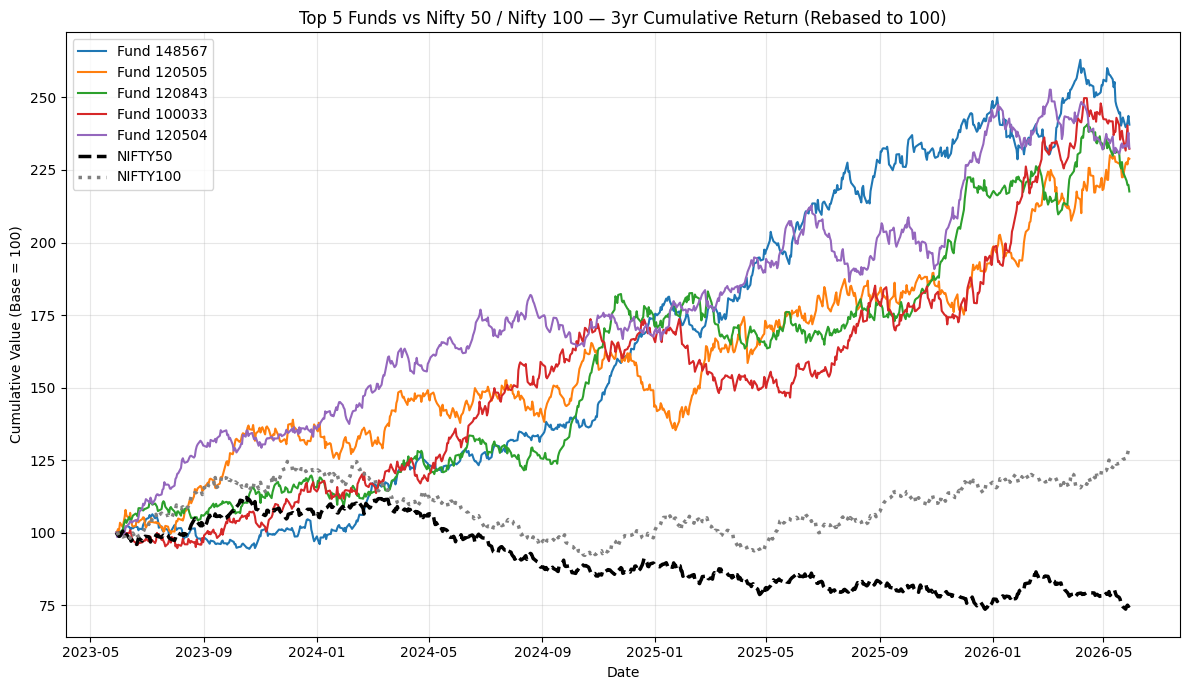

In [65]:
fig, ax = plt.subplots(figsize=(12, 7))

for col in top5_codes:
    ax.plot(rebased.index, rebased[col], label=f"Fund {col}", linewidth=1.5)

ax.plot(rebased.index, rebased['NIFTY50'], label='NIFTY50', linewidth=2.5, linestyle='--', color='black')
ax.plot(rebased.index, rebased['NIFTY100'], label='NIFTY100', linewidth=2.5, linestyle=':', color='gray')

ax.set_title('Top 5 Funds vs Nifty 50 / Nifty 100 — 3yr Cumulative Return (Rebased to 100)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Value (Base = 100)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "benchmark_comparison_top5.png", dpi=150)
plt.show()

**Note:** The visual divergence between fund and benchmark trajectories here reinforces the 
Task 6 finding (near-zero beta, R²≈0.0006) — the top funds trend strongly upward across the 
window while Nifty 50 trends downward, which would be highly unusual for funds genuinely 
correlated with the benchmark they're compared against.

In [66]:
tracking_error = {}

for code in top5_codes:
    fund_ret = nav_3yr_funds[code].pct_change().dropna()
    bench_ret = bench_3yr['NIFTY100'].pct_change().dropna()
    common = fund_ret.index.intersection(bench_ret.index)
    diff = fund_ret.reindex(common) - bench_ret.reindex(common)
    tracking_error[code] = diff.std() * np.sqrt(252)

te_df = pd.Series(tracking_error, name='tracking_error').sort_values(ascending=False)
print(te_df)

120505    0.232661
100033    0.224976
120843    0.206540
148567    0.187974
120504    0.187299
Name: tracking_error, dtype: float64


**Note:** Tracking error here (18.7%–23.3% annualized) is far above what's typical for actively 
managed funds versus their benchmark (commonly 2-8%). Combined with the near-zero beta/R² from 
the OLS regression and the visual decoupling in the chart above, this is consistent evidence 
that fund and benchmark NAV series in this dataset were generated independently rather than 
reflecting genuine market-linked performance.